In [1]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
X_train = X_train/255.0
X_test = X_test/255.0

In [4]:
model = Sequential()

model.add(Input(shape=(28, 28)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

2026-05-24 23:12:56.282312: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-24 23:12:56.282334: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-24 23:12:56.282344: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1779644576.282358 3579382 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779644576.282374 3579382 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss="sparse_categorical_crossentropy", metrics=['accuracy'], optimizer='Adam')

In [6]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=128)

Epoch 1/20


2026-05-24 23:12:56.639681: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8335 - loss: 0.5961 - val_accuracy: 0.9061 - val_loss: 0.3253
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9103 - loss: 0.3191 - val_accuracy: 0.9187 - val_loss: 0.2893
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9180 - loss: 0.2959 - val_accuracy: 0.9233 - val_loss: 0.2835
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9209 - loss: 0.2858 - val_accuracy: 0.9227 - val_loss: 0.2768
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9215 - loss: 0.2817 - val_accuracy: 0.9257 - val_loss: 0.2738
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9225 - loss: 0.2769 - val_accuracy: 0.9268 - val_loss: 0.2750
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9244 - loss: 0.2747 - val_accuracy: 0.9249 - val_loss: 0.2779
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9240 - loss: 0.2722 - val_accuracy: 0.9248 - val_

In [7]:
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [8]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9214

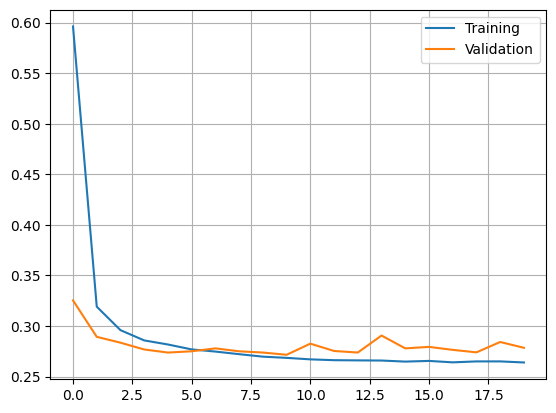

In [9]:
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.grid()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


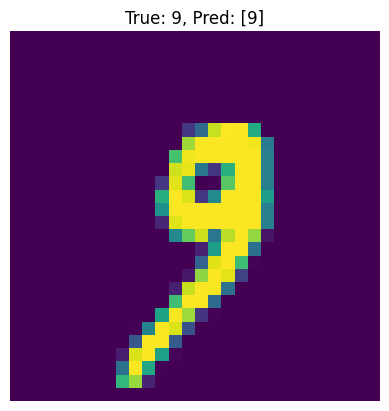

In [10]:
j = 1000
y_true = y_test[j]
y_pred = model.predict(X_test[j].reshape(1, 28, 28)).argmax(axis=1)

plt.imshow(X_test[j])
plt.title(f"True: {y_true}, Pred: {y_pred}")
plt.axis("off")
plt.show()